In [147]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns
import colorcet as cc
import sklearn

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors

from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.models.mil_species_detector import MILSpeciesDetector

save_dir = pathlib.Path("/its/home/kag25/experiments/v4/plots")
save_dir.mkdir(exist_ok=True, parents=True)

drop_cols = [
    'attention', 'classifiers', 'clf_regulariser',
    'attn_regulariser', 'beta', 'gamma_clf', 'gamma_attn',
    'label_smoothing', 'clf_learning_rate', 'attn_learning_rate',
    # 'epoch'
]

model_map = {
    "lumpy-gibson": "VAE",
    "slow-partner": "VAE",
    "unique-tiger": "VAE",
    "jumpy-engine": "VAE",
    "quaint-pilot": "VAE",
    "numb-chef": "VAE",
    "just-drum": "SIVAE", 
    "dynamic-malta": "SIVAE", 
    "daring-system": "SIVAE", 
    "earthy-virgo": "SIVAE",
    "part-armor": "SIVAE",
    "secluded-montana": "SIVAE",
    "birdnet_8": "BirdNET (FT)",
    "birdnet_16": "BirdNET (FT)", 
    "birdnet_24": "BirdNET (FT)"
}

In [140]:
scope = "SO_UK"
model_name = "just-drum"

model_path = pathlib.Path(f"/its/home/kag25/models/v4/species_detectors/{model_name}_{scope}.ckpt")
model_1 = MILSpeciesDetector.load_from_checkpoint(model_path).eval()
features_1 = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/val/features.parquet").reset_index()
scores_1 = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/val_scores.parquet/model_just-drum_run_id=dutiful-boxer_epoch=350.parquet").reset_index(drop=True)
scores_1 = scores_1.drop(drop_cols, axis=1)
scores_1["model"] = scores_1["model"].map(model_map)
scores_1.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,epoch
0,Emberiza calandra_Corn Bunting,0.264624,0.799482,88,dutiful-boxer,SIVAE,SO_UK,8,350
1,Branta canadensis_Canada Goose,0.033911,0.746094,28,dutiful-boxer,SIVAE,SO_UK,8,350
2,Garrulus glandarius_Eurasian Jay,0.005714,0.461300,20,dutiful-boxer,SIVAE,SO_UK,8,350
3,Regulus regulus_Goldcrest,0.120921,0.756329,46,dutiful-boxer,SIVAE,SO_UK,8,350
4,Cyanistes caeruleus_Eurasian Blue Tit,0.363774,0.760417,239,dutiful-boxer,SIVAE,SO_UK,8,350


In [141]:
scope = "SO_UK"
model_name = "birdnet_8"

model_path = pathlib.Path(f"/its/home/kag25/models/v4/birdnet_species_detectors/{model_name}_{scope}.ckpt")
model_2 = MILSpeciesDetector.load_from_checkpoint(model_path).eval()
scores_2 = pd.read_parquet(f"/its/home/kag25/experiments/v4/birdnet_species_detectors/val_scores.parquet/model_birdnet_8_run_id=quick-tobacco_epoch=300.parquet").reset_index(drop=True)
scores_2 = scores_2.drop(drop_cols, axis=1)
scores_2["model"] = scores_2["model"].map(model_map)
scores_2.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,epoch
0,Calidris alpina_Dunlin,0.871429,0.995043,25,quick-tobacco,BirdNET (FT),SO_UK,8,300
1,Cuculus canorus_Common Cuckoo,0.841733,0.977924,126,quick-tobacco,BirdNET (FT),SO_UK,8,300
2,Emberiza calandra_Corn Bunting,0.975650,0.997806,85,quick-tobacco,BirdNET (FT),SO_UK,8,300
3,Sylvia borin_Garden Warbler,0.866567,0.993590,43,quick-tobacco,BirdNET (FT),SO_UK,8,300
4,Columba palumbus_Common Wood-Pigeon,0.901750,0.950601,436,quick-tobacco,BirdNET (FT),SO_UK,8,300


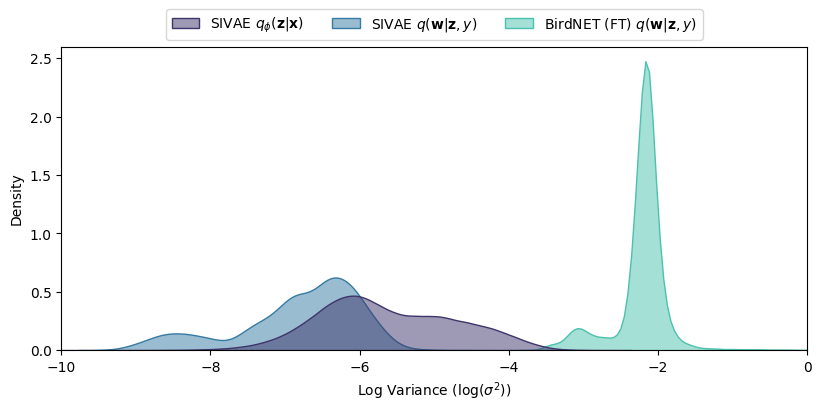

In [142]:
fig, ax = plt.subplots(figsize=(8.1, 4), constrained_layout=True)
z_log_var = features_1.loc[:, [f"z_log_var_{i}" for i in range(128)]].melt().drop("variable", axis=1)
z_log_var["dist"] = r"SIVAE $q_{\phi}(\mathbf{z}|\mathbf{x})$"
w_log_var_1 = pd.DataFrame(data=model_1.classifiers.weight_log_var.detach().numpy().flatten(), columns=["value"])
w_log_var_1["dist"] = r"SIVAE $q(\mathbf{w}|\mathbf{z},y)$"

w_log_var_2 = pd.DataFrame(data=model_2.classifiers.weight_log_var.detach().numpy().flatten(), columns=["value"])
w_log_var_2["dist"] = r"BirdNET (FT) $q(\mathbf{w}|\mathbf{z},y)$"

sns.kdeplot(pd.concat([z_log_var, w_log_var_1, w_log_var_2], axis=0), x="value", hue="dist", common_norm=False, ax=ax, fill=True, alpha=0.5, legend=True, palette="mako")
sns.move_legend(ax, loc="lower center", bbox_to_anchor=(0.5,1.0), ncols=3, title="")
ax.set_xlim(right=0.0, left=-10)
ax.set_xlabel(r"Log Variance ($\log(\sigma^2)$)")
ax.set_ylabel("Density")

plt.show()

In [146]:
data_1 = list(zip(model_1.target_names, *model_1.classifiers.weight_mu.t().detach().cpu().numpy(), *model_1.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
species_weight_var_1 = pd.DataFrame(data=data_1, columns=["species_name", *[f"mu_{i}" for i in range(model_1.classifiers.weight_log_var.size(1))], *[i for i in range(model_1.classifiers.weight_log_var.size(1))]])
species_weight_var_1 = species_weight_var_1.reset_index()
species_weight_var_1.head()

data_2 = list(zip(model_2.target_names, *model_2.classifiers.weight_mu.t().detach().cpu().numpy(), *model_2.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
species_weight_var_2 = pd.DataFrame(data=data_2, columns=["species_name", *[f"mu_{i}" for i in range(model_2.classifiers.weight_log_var.size(1))], *[f"log_var_{i}" for i in range(model_2.classifiers.weight_log_var.size(1))]])
species_weight_var_2 = species_weight_var_2.reset_index()
species_weight_var_2.head()

species_weight_var_1

,index,species_name,mu_0,mu_1,mu_2,mu_3,mu_4,mu_5,mu_6,mu_7,...,118,119,120,121,122,123,124,125,126,127
0,0,Emberiza calandra_Corn Bunting,-0.174684,-0.286812,0.006521,0.090257,-0.005403,0.005854,-0.000850,-0.001902,...,0.000982,0.001076,0.001113,0.000742,0.000967,0.001098,0.001007,0.000848,0.000778,0.000895
1,1,Branta canadensis_Canada Goose,0.433766,-0.019722,-0.060596,0.004382,0.005992,-0.070869,-0.001887,-0.688129,...,0.001581,0.001457,0.001477,0.001420,0.001909,0.001312,0.001234,0.001723,0.002076,0.001399
2,2,Garrulus glandarius_Eurasian Jay,-0.009710,-0.784160,-0.040550,0.007178,0.007849,-0.011152,0.029513,-0.004127,...,0.001725,0.001682,0.001975,0.001759,0.002044,0.001672,0.001934,0.001576,0.002057,0.001850
3,3,Regulus regulus_Goldcrest,-0.000182,-0.002553,-0.009669,-0.778106,-0.001245,0.099119,0.009657,0.032295,...,0.000960,0.001136,0.001041,0.000975,0.000942,0.000820,0.000854,0.000932,0.000962,0.001070
4,4,Cyanistes caeruleus_Eurasian Blue Tit,-1.020212,-0.134262,0.385404,-0.188287,-0.859876,1.066341,-0.024695,-0.608095,...,0.000674,0.000733,0.000890,0.000650,0.000606,0.000544,0.000478,0.000544,0.000527,0.000588
5,5,Acrocephalus scirpaceus_Eurasian Reed Warbler,0.019722,-0.003537,0.311033,-0.001458,-0.012587,0.171477,0.023001,-0.395113,...,0.001753,0.001527,0.001603,0.001850,0.001803,0.001207,0.001669,0.001611,0.001783,0.001382
6,6,Columba palumbus_Common Wood-Pigeon,0.052464,0.234616,0.271576,-0.060176,0.255387,0.478305,0.001887,0.004317,...,0.000285,0.000336,0.000200,0.000224,0.000229,0.000157,0.000196,0.000234,0.000261,0.000247
7,7,Emberiza citrinella_Yellowhammer,-0.140683,-0.158806,-0.002485,0.004872,0.023204,-0.392871,-0.014181,-0.009541,...,0.000861,0.000853,0.000868,0.000704,0.000766,0.000961,0.000900,0.000553,0.000654,0.000822
8,8,Columba oenas_Stock Dove,0.405864,-0.428616,-0.000818,0.604804,0.000831,0.000755,-0.008063,-0.000023,...,0.001754,0.001885,0.001870,0.002003,0.001779,0.001637,0.001959,0.001468,0.001749,0.001722
9,9,Sturnus vulgaris_European Starling,0.017932,-0.242630,-0.012082,0.006630,0.306540,0.150641,-0.012810,0.000475,...,0.002922,0.002702,0.002557,0.003011,0.003125,0.002810,0.002254,0.002469,0.002947,0.003012


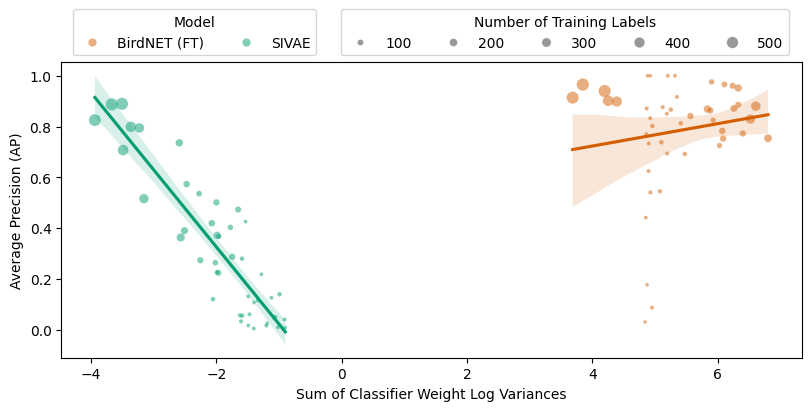

In [54]:
data_1 = list(zip(model_1.target_names, *model_1.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
species_weight_var_1 = pd.DataFrame(data=data_1, columns=["species_name", *[i for i in range(model_1.classifiers.weight_log_var.size(1))]])
species_weight_var_1 = species_weight_var_1.reset_index()
species_weight_var_1.head()

data_2 = list(zip(model_2.target_names, *model_2.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
species_weight_var_2 = pd.DataFrame(data=data_2, columns=["species_name", *[i for i in range(model_2.classifiers.weight_log_var.size(1))]])
species_weight_var_2 = species_weight_var_2.reset_index()
species_weight_var_2.head()

df1 = scores_1.merge(species_weight_var_1, on="species_name", how="inner").drop("index", axis=1)
df1 = df1.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope", "run_id", "seed"])

df2 = scores_2.merge(species_weight_var_2, on="species_name", how="inner").drop("index", axis=1)
df2 = df2.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope", "run_id", "seed"])

# long_df1 = df1.melt(var_name="weight_index", value_name="weight_var", ignore_index=False).reset_index()
# long_df2 = df2.melt(var_name="weight_index", value_name="weight_var", ignore_index=False).reset_index()

# df = pd.concat([long_df1, long_df2])
# print(df.head())
# df["weight_log_var"] = np.log(df["weight_var"])

order = df1.reset_index().sort_values(by="train_label_counts", ascending=False)["species_name"].tolist()
df1 = df1.sum(axis=1).reset_index().rename(columns={0: "weight_var_sum"})
df2 = df2.sum(axis=1).reset_index().rename(columns={0: "weight_var_sum"})
df3 = pd.concat([df1, df2], axis=0)


df3["log_label_counts"] = np.log(df3["train_label_counts"])
df3["log_weight_var_sum"] = np.log(df3["weight_var_sum"])
df3["neg_log_weight_var_sum"] = -np.log(df3["weight_var_sum"])
df3["log_AP"] = np.log(df3["AP"])
df3["log_auROC"] = np.log(df3["auROC"])

fig, ax = plt.subplots(nrows=1, figsize=(8, 4), constrained_layout=True)
palette = sns.color_palette("colorblind", 4)
palette = [palette[3], palette[2]]
sns.scatterplot(
    data=df3,
    x="log_weight_var_sum",
    hue="model",
    y="AP",
    size="train_label_counts",
    sizes=(6, 80),
    size_norm=mcolors.Normalize(vmin=0, vmax=df3["train_label_counts"].max(), clip=False),
    alpha=0.75,
    hue_order=["BirdNET (FT)", "SIVAE"],
    palette=palette,
    ax=ax,
    legend=True
)
for model_name, color in zip(["BirdNET (FT)", "SIVAE"], palette):
    sns.regplot(data=df3[df3["model"] == model_name], x="log_weight_var_sum", y="AP", color=color, ax=ax, scatter=False)

handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
size_start = labels.index("train_label_counts")
hue_handles = handles[1:size_start]
hue_labels = labels[1:size_start]

size_handles = handles[size_start+1:]
size_labels = labels[size_start+1:]

leg1 = ax.legend(size_handles, size_labels, title="Number of Training Labels", bbox_to_anchor=(0.68, 1), loc="lower center", ncols=5)
ax.add_artist(leg1)
ax.legend(hue_handles, hue_labels, title="Model", bbox_to_anchor=(0.18, 1), loc="lower center", ncols=2)

ax.set_ylabel("Average Precision (AP)")
ax.set_xlabel(r"Sum of Classifier Weight Log Variances")

plt.show()

In [45]:
df3["train_label_counts"].min()

11

---

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

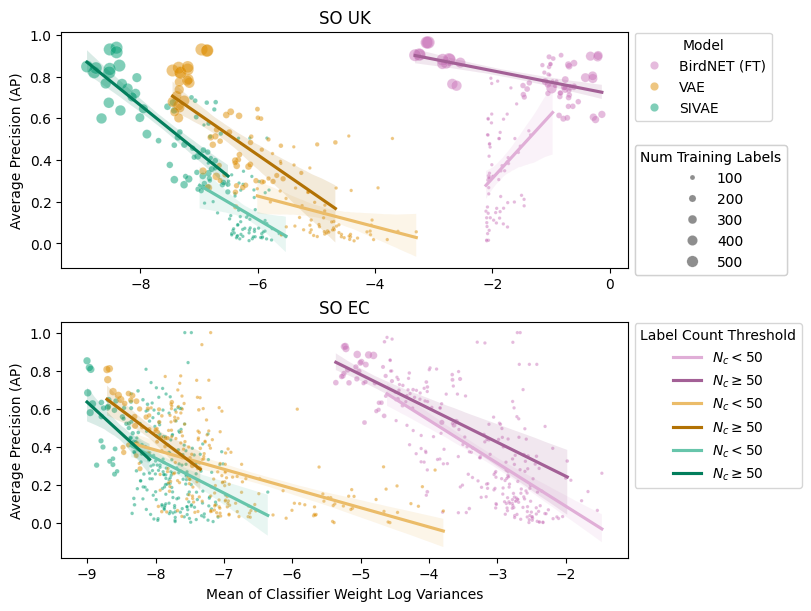

In [161]:
scopes = {
    "SO_UK": {
        "VAE": (["lumpy-gibson", "slow-partner", "unique-tiger"], ["rich-state", "woolly-symbol", "eminent-bombay"]),
        "SIVAE": (["just-drum", "dynamic-malta", "daring-system"], ["dutiful-boxer", "amuck-ricardo", "thin-connect"]),
        "BirdNET (FT)": (["birdnet_8", "birdnet_16", "birdnet_24"], ["quick-tobacco", "exciting-telex", "simple-donald"]),
    },
    "SO_EC": {
        "VAE": (["lumpy-gibson", "slow-partner", "unique-tiger"], ["live-spoon", "mellow-arrow", "golden-degree"]),
        "SIVAE": (["just-drum", "dynamic-malta", "daring-system"], ["robust-nadia", "bored-moral", "primo-support"]),
        "BirdNET (FT)": (["birdnet_8", "birdnet_16", "birdnet_24"], ["average-shake", "papal-laptop", "gross-danube"]),
    },
    # "RFCX_bird": {
    #     "SIVAE": (["earthy-virgo", "part-armor", "secluded-montana"], ["dazzling-albert", "complex-eternal", "venomous-front"]),
    #     "BirdNET (FT)": (["birdnet_8", "birdnet_16", "birdnet_24"], ["equal-alaska", "strong-cyclone", "partial-tornado"]),
    # },
    # "RFCX_frog": {
    #     "SIVAE": (["earthy-virgo", "part-armor", "secluded-montana"], ["cautious-family", "small-zipper", "angry-family"]),
    #     "BirdNET (FT)": (["birdnet_8", "birdnet_16", "birdnet_24"], ["regal-soda", "light-flipper", "itchy-static"]),

    # },
}

fig, axes = plt.subplots(nrows=2, figsize=(8, 6), constrained_layout=True)

def darken_color(color, amount=0.7):
    return tuple(amount * channel for channel in mcolors.to_rgb(color))

def lighten_color(color, amount=0.7):
    return tuple(1 - (1 - channel) * amount for channel in mcolors.to_rgb(color))

thresh = 50
max_count = 600
for i, (scope, ax) in enumerate(zip(scopes.keys(), axes.flatten())):
    model_names_1, run_names = scopes[scope]["SIVAE"]
    models_1 = []
    scores_1 = []
    for model_name, run in zip(model_names_1, run_names):
        model_path = pathlib.Path(f"/its/home/kag25/models/v4/species_detectors/{model_name}_{scope}.ckpt")
        model_1 = MILSpeciesDetector.load_from_checkpoint(model_path).eval()
        models_1.append(model_1)
        scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{model_name}_run_id={run}.parquet").reset_index(drop=True)
        scores = scores.drop(drop_cols, axis=1)
        scores["run_id"] = scores["model"]
        scores["model"] = scores["model"].map(model_map)
        scores_1.append(scores)
    scores_1 = pd.concat(scores_1, axis=0)
    scores_1.head()

    species_weight_var_1 = []
    for model_name, model in zip(model_names_1, models_1):
        data = list(zip(model.target_names, *model.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
        species_weight_var = pd.DataFrame(data=data, columns=["species_name", *[i for i in range(model.classifiers.weight_log_var.size(1))]])
        species_weight_var["run_id"] = model_name
        species_weight_var_1.append(species_weight_var.reset_index())
    species_weight_var_1 = pd.concat(species_weight_var_1)

    df1 = scores_1.merge(species_weight_var_1, on=["species_name", "run_id"], how="inner").drop("index", axis=1)
    df1 = df1.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope", "run_id", "seed"])
    
    model_names_2, run_names = scopes[scope]["BirdNET (FT)"]
    models_2 = []
    scores_2 = []
    for model_name, run in zip(model_names_2, run_names):
        model_path = pathlib.Path(f"/its/home/kag25/models/v4/birdnet_species_detectors/{model_name}_{scope}.ckpt")
        model_2 = MILSpeciesDetector.load_from_checkpoint(model_path).eval()
        models_2.append(model_2)
        scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/birdnet_species_detectors/test_scores.parquet/model_{model_name}_run_id={run}.parquet").reset_index(drop=True)
        scores = scores.drop(drop_cols, axis=1)
        scores["run_id"] = scores["model"]
        scores["model"] = scores["model"].map(model_map)
        scores_2.append(scores)
    scores_2 = pd.concat(scores_2, axis=0)
    scores_2.head()
    
    species_weight_var_2 = []
    for model_name, model in zip(model_names_2, models_2):
        data = list(zip(model.target_names, *model.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
        species_weight_var = pd.DataFrame(data=data, columns=["species_name", *[i for i in range(model.classifiers.weight_log_var.size(1))]])
        species_weight_var["run_id"] = model_name
        species_weight_var_2.append(species_weight_var.reset_index())
    species_weight_var_2 = pd.concat(species_weight_var_2)
    species_weight_var_2
    
    df2 = scores_2.merge(species_weight_var_2, on=["species_name", "run_id"], how="inner").drop("index", axis=1)
    df2 = df2.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope", "run_id", "seed"])

    model_names_3, run_names = scopes[scope]["VAE"]
    models_3 = []
    scores_3 = []
    for model_name, run in zip(model_names_3, run_names):
        model_path = pathlib.Path(f"/its/home/kag25/models/v4/species_detectors/{model_name}_{scope}.ckpt")
        model_3 = MILSpeciesDetector.load_from_checkpoint(model_path).eval()
        models_3.append(model_3)
        scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{model_name}_run_id={run}.parquet").reset_index(drop=True)
        scores = scores.drop(drop_cols, axis=1)
        scores["run_id"] = scores["model"]
        scores["model"] = scores["model"].map(model_map)
        scores_3.append(scores)
    scores_3 = pd.concat(scores_3, axis=0)
    scores_3.head()
    
    species_weight_var_3 = []
    for model_name, model in zip(model_names_3, models_3):
        data = list(zip(model.target_names, *model.classifiers.weight_log_var.exp().t().detach().cpu().numpy()))
        species_weight_var = pd.DataFrame(data=data, columns=["species_name", *[i for i in range(model.classifiers.weight_log_var.size(1))]])
        species_weight_var["run_id"] = model_name
        species_weight_var_3.append(species_weight_var.reset_index())
    species_weight_var_3 = pd.concat(species_weight_var_3)
    species_weight_var_3
    
    df4 = scores_3.merge(species_weight_var_3, on=["species_name", "run_id"], how="inner").drop("index", axis=1)
    df4 = df4.set_index(["species_name", "AP", "auROC", "train_label_counts", "model", "scope", "run_id", "seed"])

    
    df1 = df1.mean(axis=1).reset_index().rename(columns={0: "weight_var_sum"})
    df2 = df2.mean(axis=1).reset_index().rename(columns={0: "weight_var_sum"})
    df4 = df4.mean(axis=1).reset_index().rename(columns={0: "weight_var_sum"})

    df3 = pd.concat([df1, df2, df4], axis=0)
    
    df3["log_label_counts"] = np.log(df3["train_label_counts"])
    df3["log_weight_var_sum"] = np.log(df3["weight_var_sum"])
    df3["neg_log_weight_var_sum"] = -np.log(df3["weight_var_sum"])
    df3["log_AP"] = np.log(df3["AP"])
    df3["log_auROC"] = np.log(df3["auROC"])
    
    palette = sns.color_palette("colorblind", 5)
    palette = [palette[4], palette[1], palette[2]]
    sns.scatterplot(
        data=df3,
        x="log_weight_var_sum",
        hue="model",
        y="AP",
        size="train_label_counts",
        sizes=(6, 80),
        size_norm=mcolors.Normalize(vmin=thresh, vmax=max_count, clip=False),
        alpha=0.5,
        hue_order=["BirdNET (FT)", "VAE", "SIVAE"],
        palette=palette,
        ax=ax,
        legend=True
    )
    for model_name, color in zip(["BirdNET (FT)", "VAE", "SIVAE"], palette):
        sns.regplot(data=df3[(df3["model"] == model_name) & (df3["train_label_counts"] < thresh)], x="log_weight_var_sum", y="AP", color=lighten_color(color, 0.6), ax=ax, scatter=False, label=rf"$N_c < {thresh}$")
        sns.regplot(data=df3[(df3["model"] == model_name) & (df3["train_label_counts"] >= thresh)], x="log_weight_var_sum", y="AP", color=darken_color(color, 0.8), ax=ax, scatter=False, label=rf"$N_c \geq {thresh}$")
    
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    # ax.set_xlim(left=-5, right=7)

    if i == 0:
        size_start = labels.index("train_label_counts")
        hue_handles = handles[1:size_start]
        hue_labels = labels[1:size_start]
        leg_top = ax.legend(hue_handles, hue_labels, title="Model", bbox_to_anchor=(1, 1.025), loc="upper left", ncols=1)
        ax.add_artist(leg_top)
        for t in leg_top.get_texts():
            t.set_ha('left')

        size_handles = handles[size_start+1:-6]
        size_labels = labels[size_start+1:-6]
    
        leg_right = ax.legend(
            size_handles,
            size_labels,
            title="Num Training Labels",
            bbox_to_anchor=(1, 0.55),
            loc="upper left",
        )
        ax.add_artist(leg_right)
        for t in leg_top.get_texts():
            t.set_ha('left')


    if i == 1:
        reg_handles = handles[-6:]
        reg_labels = labels[-6:]
        l = ax.legend(
            reg_handles,
            reg_labels,
            title="Label Count Threshold",
            bbox_to_anchor=(1, 1.025),
            loc="upper left",
        )
        for t in l.get_texts():
            t.set_ha('left')


    if i == 1:
        ax.set_xlabel(r"Mean of Classifier Weight Log Variances")
    else:
        ax.set_xlabel("")

    ax.set_ylabel("Average Precision (AP)")
    ax.set_title(scope.replace("_", " "))

fig.savefig(save_dir / "precision_uncertainty_count.pdf", format="pdf", bbox_inches="tight")
plt.show()